In [15]:
from src.gmm import GMM
from src.dg import DataGenerator

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, logistic, t


# PART I: Iterative EM -- Comparing AIC, BIC, and loglik over $k$ on simulated data

## Data generating

In [16]:
# param_vals
dist = 'Logistic' # Logistic, Normal, Student t
alpha = 0.7
d = 3
N = 2000

#df = 3 # for Student t in particular

dg = DataGenerator(dist, alpha)
X, M = dg.generate(N, d)

In [17]:
def true_quantile(dist, q=0.1, df=None):
    if dist == 'Normal':
        return norm.ppf(q)
    elif dist == 'Logistic':
        return logistic.ppf(q)
    elif dist == 'Student t':
        return t.ppf(q, df)

## Iterative EM

In [18]:
# GMM settings
cov_type = 'uni_diag' # diag, id, uni_diag, uni_id
n_k = 5
start = 0
step = 1
n_mc = 500

In [19]:
gmm = GMM(X, M, cov_type)
kk, q, loglik, aic, bic = gmm.iterEM(n_k, start, step, n_mc)

0 1.00 -9599.84 19211.68 19245.28
Converged at iteration 1, rel_change=0.00e+00
1 2.00 -9599.84 19219.68 19275.68
Converged at iteration 1, rel_change=0.00e+00
2 3.00 -9599.84 19227.68 19306.09
Converged at iteration 1, rel_change=0.00e+00
3 4.00 -9599.84 19235.68 19336.49
Converged at iteration 1, rel_change=0.00e+00
4 5.00 -9599.84 19243.68 19366.90


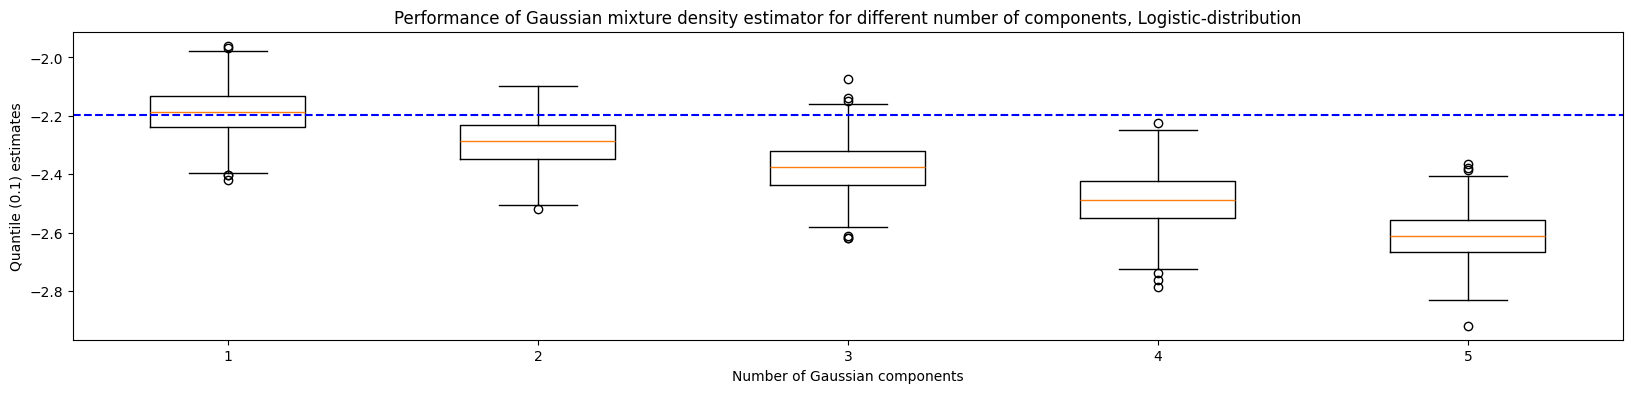

In [20]:
positions = np.array(kk)

plt.figure(figsize=(20, 4))
plt.boxplot(q.T, positions=positions)

plt.axhline(y=true_quantile(dist), color='blue', linestyle='--')
plt.xlabel("Number of Gaussian components")
plt.ylabel("Quantile (0.1) estimates")
plt.xticks(positions, positions.astype(int))
plt.title(f'Performance of Gaussian mixture density estimator for different number of components, {dist}-distribution')
plt.show()

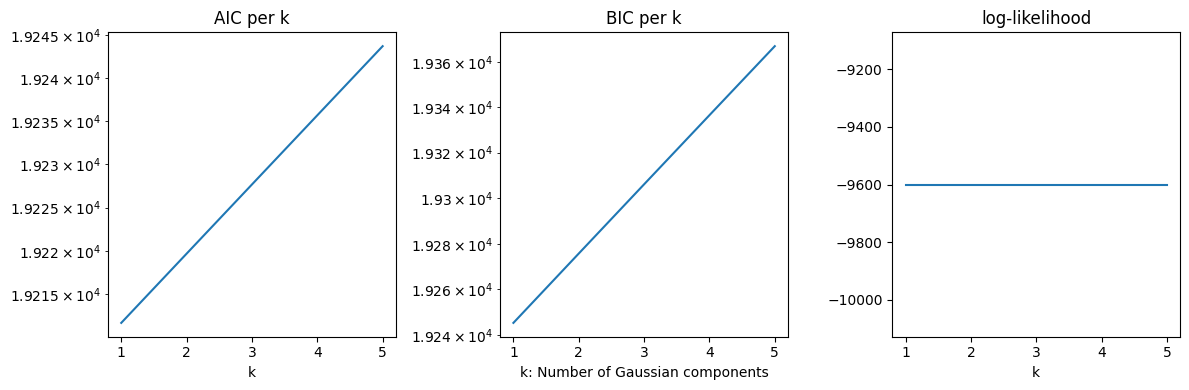

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].plot(kk, aic)
axs[0].set_yscale('log')
axs[0].set_xlabel('k')
axs[0].set_title('AIC per k')

axs[1].plot(kk, bic)
axs[1].set_yscale('log')
axs[1].set_xlabel('k: Number of Gaussian components')
axs[1].set_title('BIC per k')

axs[2].plot(kk, loglik)
axs[2].set_xlabel('k')
axs[2].set_title('log-likelihood')

plt.tight_layout()
plt.show()

# PART II: Real data